# Shortwave Radiation Budget Calibration

This notebook calibrates **9 shortwave radiation parameters** in SpeedyWeather.jl to match the [Trenberth et al. (2009)](https://doi.org/10.1175/2008BAMS2634.1) global energy budget targets:

| Flux | Target | Description |
|------|--------|-------------|
| OSR  | 101.9 W/m² | Outgoing shortwave at top-of-atmosphere |
| SRU  | 23.0 W/m²  | Surface shortwave reflected upward |
| SRD  | 168.0 W/m² | Surface shortwave absorbed downward |

The method is **online statistical gradient estimation**: we run the model continuously and average single-timestep Enzyme gradients to estimate ∂L/∂θ robustly under chaotic dynamics — no long-trajectory differentiation, no exploding gradients.

**Expected runtime:** ~6–8 hours at T31. Use the quick-test section (Section 4) first to verify everything works.

## 1. Setup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using SpeedyCalibration
using Optimisers
using CairoMakie
using Dates
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
Precompiling packages...
 134964.6 ms  ✓ SpeedyCalibration
  1 dependency successfully precompiled in 136 seconds. 201 already precompiled.
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
[ Info: Precompiling ModelParametersUnitfulExt [30a72cc9-359b-520d-a5bb-2064a7c97f0f]
[ Info: Precompiling ModelParametersMakieExt [fe55f67a-76af-556c-8c6e-f9ee716b975d]
[ Info: Precompiling DomainSetsMakieExt [da481366-01c8-5b4d-b359-47a10c8532e7]
[ Info: Precompiling RingGridsMakieExt [e5dccbbd-f882-5bb0-bb40-f730cea6c903]
[ Info: Precompiling SpeedyCalibrationMakieExt [657b58ae-5d3d-567e-a598-44252c96ac46]


## 2. Define Trainable Parameters

Each `ParamSpec` describes one trainable parameter:
- **`path`** — property chain into the model, e.g. `[:shortwave_radiation, :clouds, :cloud_albedo]` corresponds to `model.shortwave_radiation.clouds.cloud_albedo`
- **`bounds`** — physical `(lb, ub)`; enforced via sigmoid reparameterisation (no clamping)
- **`initial`** — starting value; `nothing` reads the current model default
- **`grad_scale`** — per-parameter gradient multiplier for parameters with numerically weak gradients

We start all parameters **below** their default values to create a low-albedo, high-absorption initial state — a deliberate bias that gives the optimiser a clear gradient direction from the first batch.

In [3]:
param_specs = [
    # ── SW cloud reflection ───────────────────────────────────────────────────
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),

    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),

    ParamSpec(:stratocumulus_albedo,
        [:shortwave_radiation, :clouds, :stratocumulus_albedo];
        bounds=(0.10f0, 0.90f0), initial=0.50f0),

    # ── SW atmospheric absorption ─────────────────────────────────────────────
    # absorptivity_water_vapor has a ~200× weaker physical gradient (multiplied
    # by specific humidity q ≈ 0.005); grad_scale compensates.
    # Stability floor: model becomes numerically unstable below lb ≈ 57.
    ParamSpec(:absorptivity_water_vapor,
        [:shortwave_radiation, :transmissivity, :absorptivity_water_vapor];
        bounds=(60f0, 140f0), initial=75f0, grad_scale=0.01f0),

    ParamSpec(:absorptivity_dry_air,
        [:shortwave_radiation, :transmissivity, :absorptivity_dry_air];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),

    ParamSpec(:ozone_absorption,
        [:shortwave_radiation, :radiative_transfer, :ozone_absorption];
        bounds=(0.002f0, 0.020f0), initial=0.01f0),

    # ── Land surface albedo ───────────────────────────────────────────────────
    ParamSpec(:albedo_land,
        [:albedo, :land, :albedo_land];
        bounds=(0.10f0, 0.70f0), initial=0.40f0),

    ParamSpec(:albedo_high_vegetation,
        [:albedo, :land, :albedo_high_vegetation];
        bounds=(0.04f0, 0.26f0), initial=0.15f0),

    ParamSpec(:albedo_low_vegetation,
        [:albedo, :land, :albedo_low_vegetation];
        bounds=(0.05f0, 0.35f0), initial=0.20f0),

    ParamSpec(:albedo_snow,
        [:albedo, :land, :albedo_snow];
        bounds=(0.15f0, 0.75f0), initial=0.40f0),

    # ── Ocean surface albedo ──────────────────────────────────────────────────
    ParamSpec(:albedo_ocean,
        [:albedo, :ocean, :albedo_ocean];
        bounds=(0.02f0, 0.10f0), initial=0.06f0),
]

println("$(length(param_specs)) trainable parameters defined.")


11 trainable parameters defined.


## 3. Configure the Loss Function

`OSR_SRU_SRD_LOSS` is a pre-built `LossConfig` targeting the three shortwave budget fluxes with equal weights. You can inspect the targets:

In [4]:
loss_config = OSR_SRU_SRD_LOSS

println("Loss configuration: $(length(loss_config.flux_keys))-flux MSE")
for k in loss_config.flux_keys
    @printf("  %4s  target = %6.1f W/m²  weight = %.1f\n",
            k, loss_config.targets[k], loss_config.weights[k])
end

Loss configuration: 3-flux MSE
   osr  target =  101.9 W/m²  weight = 1.0
   sru  target =   23.0 W/m²  weight = 1.0
   srd  target =  168.0 W/m²  weight = 1.0


## 4. Quick Test (verify everything works)

Before committing to the full 6–8 hour run, always do a quick test at low resolution to verify that parameter paths are correct, bounds are sensible, and Enzyme can differentiate through the model. This takes ~2–5 minutes.

> **Note:** `calibrate!` automatically warms up Enzyme on the actual model before spinup (`warmup_enzyme=true` in `TrainingConfig`). The first call in a Julia session will print *"Enzyme warmup complete in X s."* — this is expected.
On a second call in the same session pass `warmup_enzyme=false` to skip it.

In [5]:
result_test = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    quick_test_config();   # trunc=5, nlayers=3, spinup=5d, 5 batches
    save_dir = joinpath(@__DIR__, "output", "radiation_sw_test"),
)

println("\nTest run complete: ", result_test.conv_info.stop_reason)
println("Final parameters:")
for (k, v) in result_test.final_params
    @printf("  %-25s = %.4f\n", k, v)
end

[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl — calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   5. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   6. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   7. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
   8. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
   9. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  10. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  11. albedo_ocean                     = 0.0600  [0.020, 0.100]  raw₀=0.000
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sr

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/NZC9j/src/output/feedback.jl:123


Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.0 s.
Starting training...
----------------------------------------------------------------------


   0%  ETA: 70.66 days (2000-03-28, 516.44 days/day, NaN m/s, [ NaN,  NaN] ˚C)

Batch 1: all gradient samples invalid, stopping.

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.6000
  stratocumulus_cover_max          0.6000 → 0.6000
  stratocumulus_albedo             0.5000 → 0.5000
  absorptivity_water_vapor         75.0000 → 75.0000
  absorptivity_dry_air             0.0314 → 0.0314
  ozone_absorption                 0.0100 → 0.0100
  albedo_land                      0.4000 → 0.4000
  albedo_high_vegetation           0.1500 → 0.1500
  albedo_low_vegetation            0.2000 → 0.2000
  albedo_snow                      0.4000 → 0.4000
  albedo_ocean                     0.0600 → 0.0600
----------------------------------------------------------------------
  (no batches completed)
Stop: all gradient samples invalid  |  time: 1201.5 s

Test run complete: all gradient samples invalid
Final parameters:
  albedo_snow               = 0.4000
  absorptivity_water_vapor  = 75.0000
  absorptivity_dry_air      = 0.0314
  albedo_ocean              = 0.0600
  al

If the quick test completed without errors and the parameters moved from their initial values, the setup is correct. Proceed to the full training run below.

---

## 5. Full Training Run

**⏱ Expected runtime: ~6–8 hours at T31.**

Key settings:
- `spinup_days=180` — 6 months to reach statistical equilibrium before collecting gradients
- `samples_per_batch=20` — 20 gradient samples averaged per batch (reduces noise)
- `batch_days=3.0` — 3 simulated days per batch; one sample every ~3.6 hours
- `max_batches=300` — hard stop at 300 batches (~900 simulated days post-spinup)

The result is automatically saved to disk so you can reload it without re-running.

In [6]:
result = calibrate!(
    param_specs,
    Optimisers.Adam(5f-3),
    loss_config,
    TrainingConfig(
        spinup_days       = 180,
        batch_days        = 3.0,
        samples_per_batch = 20,
        max_batches       = 300,
        loss_threshold    = 50f0,
        trunc             = 31,
        nlayers           = 8,
    );
    save_dir = joinpath(@__DIR__, "output", "radiation_sw"),
)
println("Artifacts saved to: ", joinpath(@__DIR__, "output", "radiation_sw"))

SpeedyCalibration.jl — calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   5. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   6. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   7. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
   8. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
   9. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  10. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  11. albedo_ocean                     = 0.0600  [0.020, 0.100]  raw₀=0.000
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sr

   0%  ETA: 2:25:05 (2000-09-16, 987.66 years/day, 109 m/s, [ -87,   29] ˚C)

Spinup complete in 45.0 s.

Warming up Enzyme (compiling AD rules on actual model)...


   0%  ETA: 10:13:03 (2000-09-17, 233.73 years/day, 106 m/s, [ -88,   27] ˚C)

Enzyme warmup complete in 139.2 s.
Starting training...
----------------------------------------------------------------------


...

Batch 170 | LR 5.0e-03 | osr= 96.3 sru= 26.0 srd=172.4 | L̄    59.97 | Δp 1.1e-03


   2%  ETA: 10:16:39 (2002-02-23, 229.01 years/day, 108 m/s, [-105,   26] ˚C)

Batch 175 | LR 5.0e-03 | osr= 97.2 sru= 25.4 srd=171.2 | L̄    53.38 | Δp 1.2e-03


   2%  ETA: 10:16:23 (2002-03-01, 229.07 years/day, 109 m/s, [-106,   26] ˚C)

CONVERGED: smoothed_loss 49.7505 < 50.0000

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.7457
  stratocumulus_cover_max          0.6000 → 0.7454
  stratocumulus_albedo             0.5000 → 0.6657
  absorptivity_water_vapor         75.0000 → 89.7093
  absorptivity_dry_air             0.0314 → 0.0419
  ozone_absorption                 0.0100 → 0.0135
  albedo_land                      0.4000 → 0.4339
  albedo_high_vegetation           0.1500 → 0.1640
  albedo_low_vegetation            0.2000 → 0.2111
  albedo_snow                      0.4000 → 0.5029
  albedo_ocean                     0.0600 → 0.0736
----------------------------------------------------------------------
  Final osr :  97.28 W/m²  (target: 101.9)
  Final sru :  25.31 W/m²  (target: 23.0)
  Final srd : 170.31 W/m²  (target: 168.0)
Final smoothed loss: 49.7505  |  best: 49.7505
Stop: smoothed loss below threshold (50.0)  |  time: 736.6 s
Artifacts saved to: /Users/niklasviebig/master_thesis/Code_SpeedyWeat

To reload a saved result later without re-running:
```julia
result = load_result(joinpath(@__DIR__, "output", "radiation_sw", "result.jld2"))
```

## 6. Inspect Results

The `TrainingResult` contains the full history, final parameter values, and convergence information.

In [7]:
println(result)
println()
println("Convergence:")
println("  stop_reason:        ", result.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=3))
println("  total_batches:      ", result.conv_info.total_batches)
@printf("  total_time:         %.1f min\n", result.conv_info.total_time / 60)

println()
println("Final vs initial parameter values:")
@printf("  %-25s  %8s  %8s  %8s\n", "name", "initial", "trained", "change")
for spec in result.param_specs
    init = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result.final_params[spec.name]
    @printf("  %-25s  %8.4f  %8.4f  %+8.4f\n",
            spec.name, init, trained, trained - init)
end

TrainingResult(177 batches, stop=smoothed loss below threshold (50.0), best_loss=49.7505)

Convergence:
  stop_reason:        smoothed loss below threshold (50.0)
  best_smoothed_loss: 49.751
  total_batches:      177
  total_time:         12.3 min

Final vs initial parameter values:
  name                        initial   trained    change
  cloud_albedo                 0.6000    0.7457   +0.1457
  stratocumulus_cover_max      0.6000    0.7454   +0.1454
  stratocumulus_albedo         0.5000    0.6657   +0.1657
  absorptivity_water_vapor    75.0000   89.7093  +14.7093
  absorptivity_dry_air         0.0314    0.0419   +0.0105
  ozone_absorption             0.0100    0.0135   +0.0035
  albedo_land                  0.4000    0.4339   +0.0339
  albedo_high_vegetation       0.1500    0.1640   +0.0140
  albedo_low_vegetation        0.2000    0.2111   +0.0111
  albedo_snow                  0.4000    0.5029   +0.1029
  albedo_ocean                 0.0600    0.0736   +0.0136


In [8]:
# Final flux values vs targets
println("Final flux means (last batch):")
for k in result.loss_config.flux_keys
    final_v = result.history[k][end]
    target  = result.loss_config.targets[k]
    @printf("  %4s: %6.2f W/m²  (target: %.1f  bias: %+.2f)\n",
            k, final_v, target, final_v - target)
end

Final flux means (last batch):
   osr:  97.28 W/m²  (target: 101.9  bias: -4.62)
   sru:  25.31 W/m²  (target: 23.0  bias: +2.31)
   srd: 170.31 W/m²  (target: 168.0  bias: +2.31)


## 7. Plot Training History

`plot_training` produces four figures:
- **`fig_loss`** — loss curve and learning rate schedule
- **`fig_flux`** — per-flux time series vs Trenberth targets
- **`fig_params`** — parameter trajectories with physical bounds
- **`fig_grads`** — gradient mean ± std per parameter

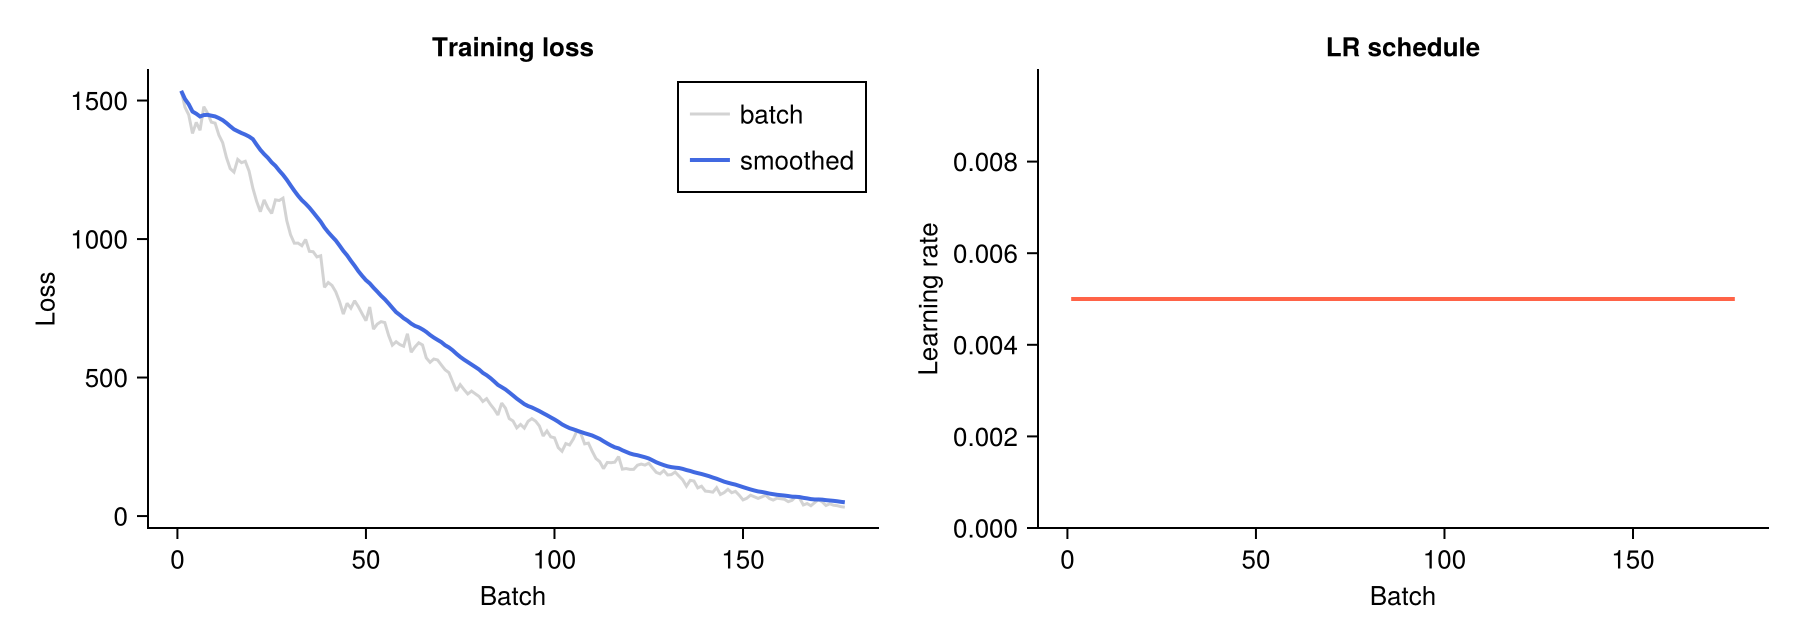

In [9]:
figs = plot_training(result; save_dir=joinpath(@__DIR__, "output", "radiation_sw"))
figs.fig_loss

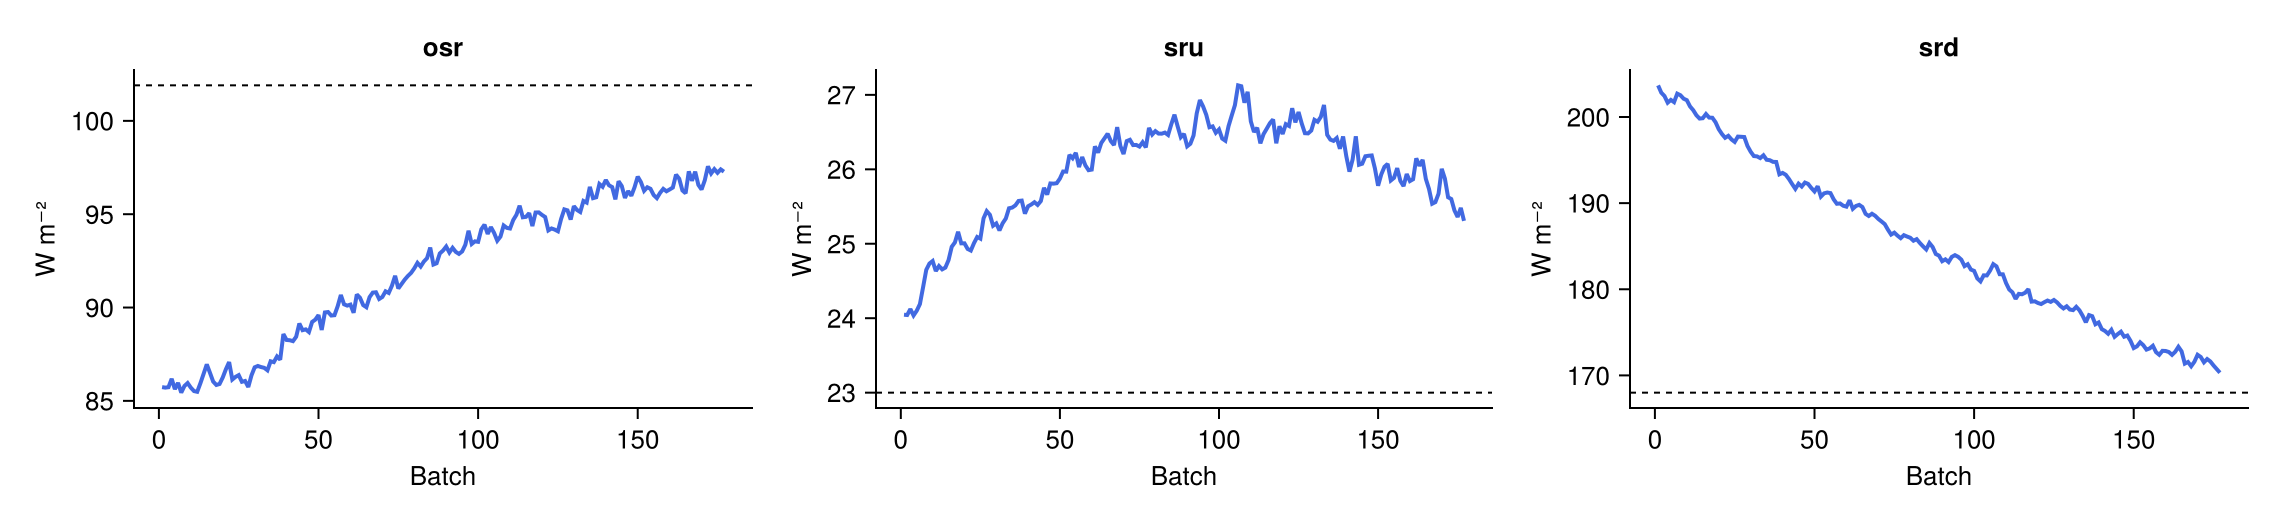

In [10]:
figs.fig_flux

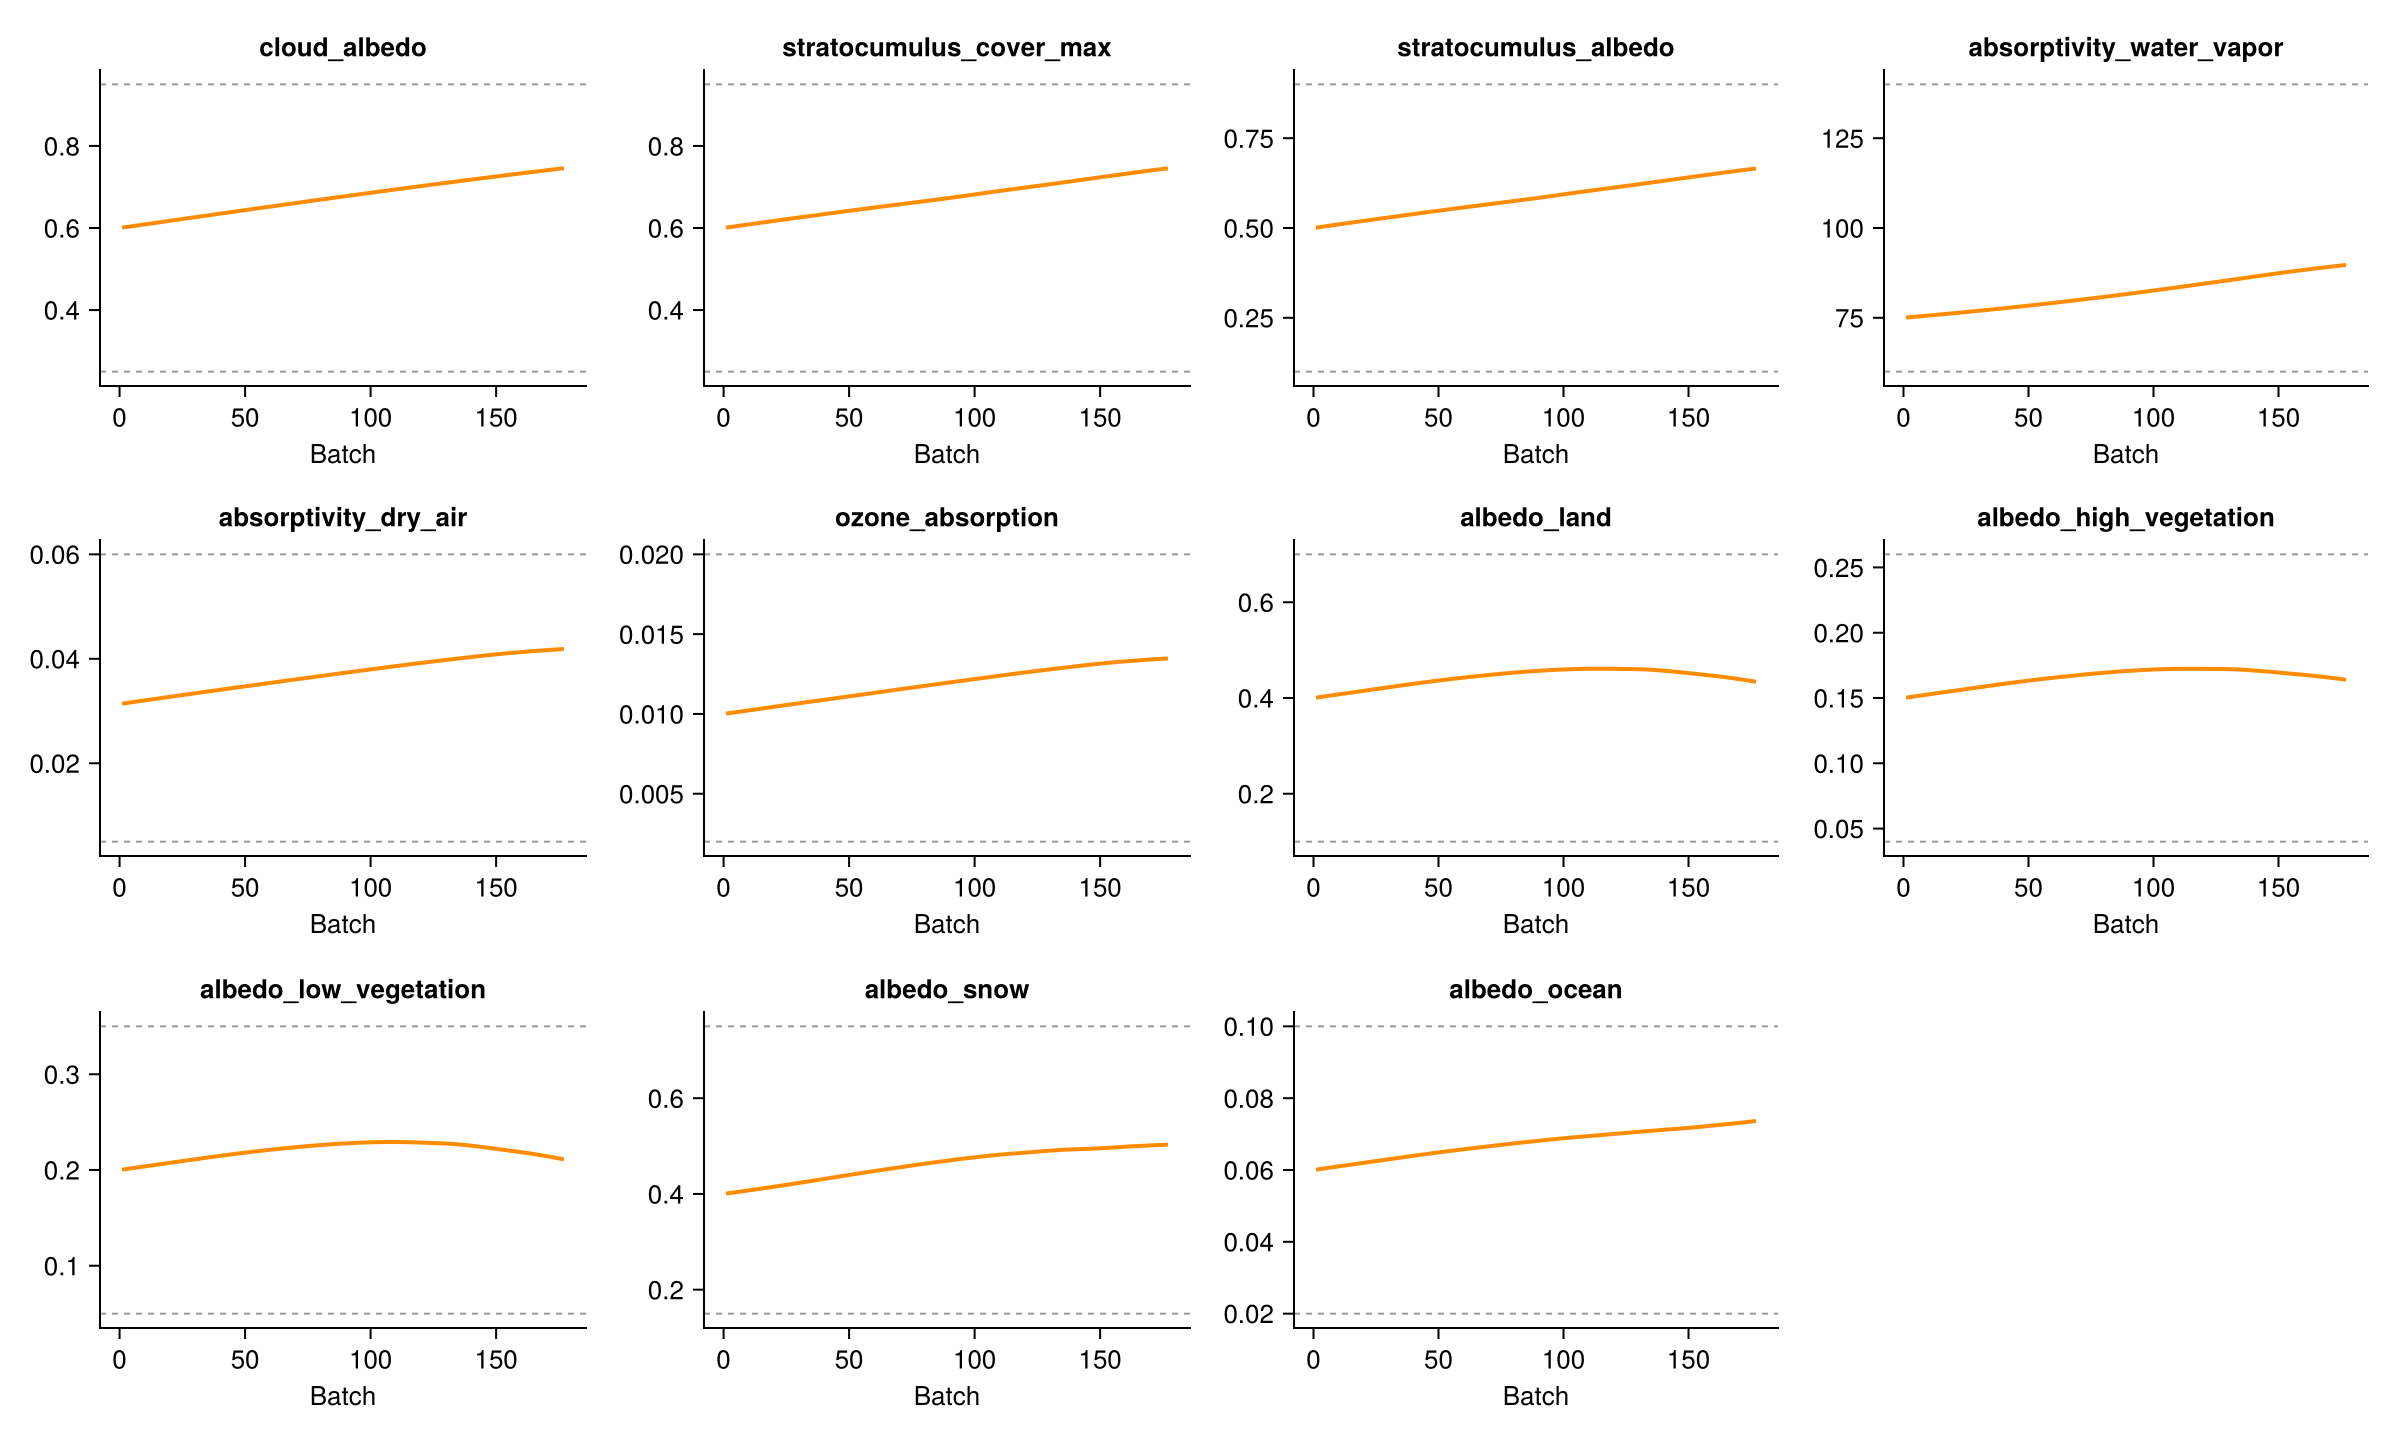

In [11]:
figs.fig_params

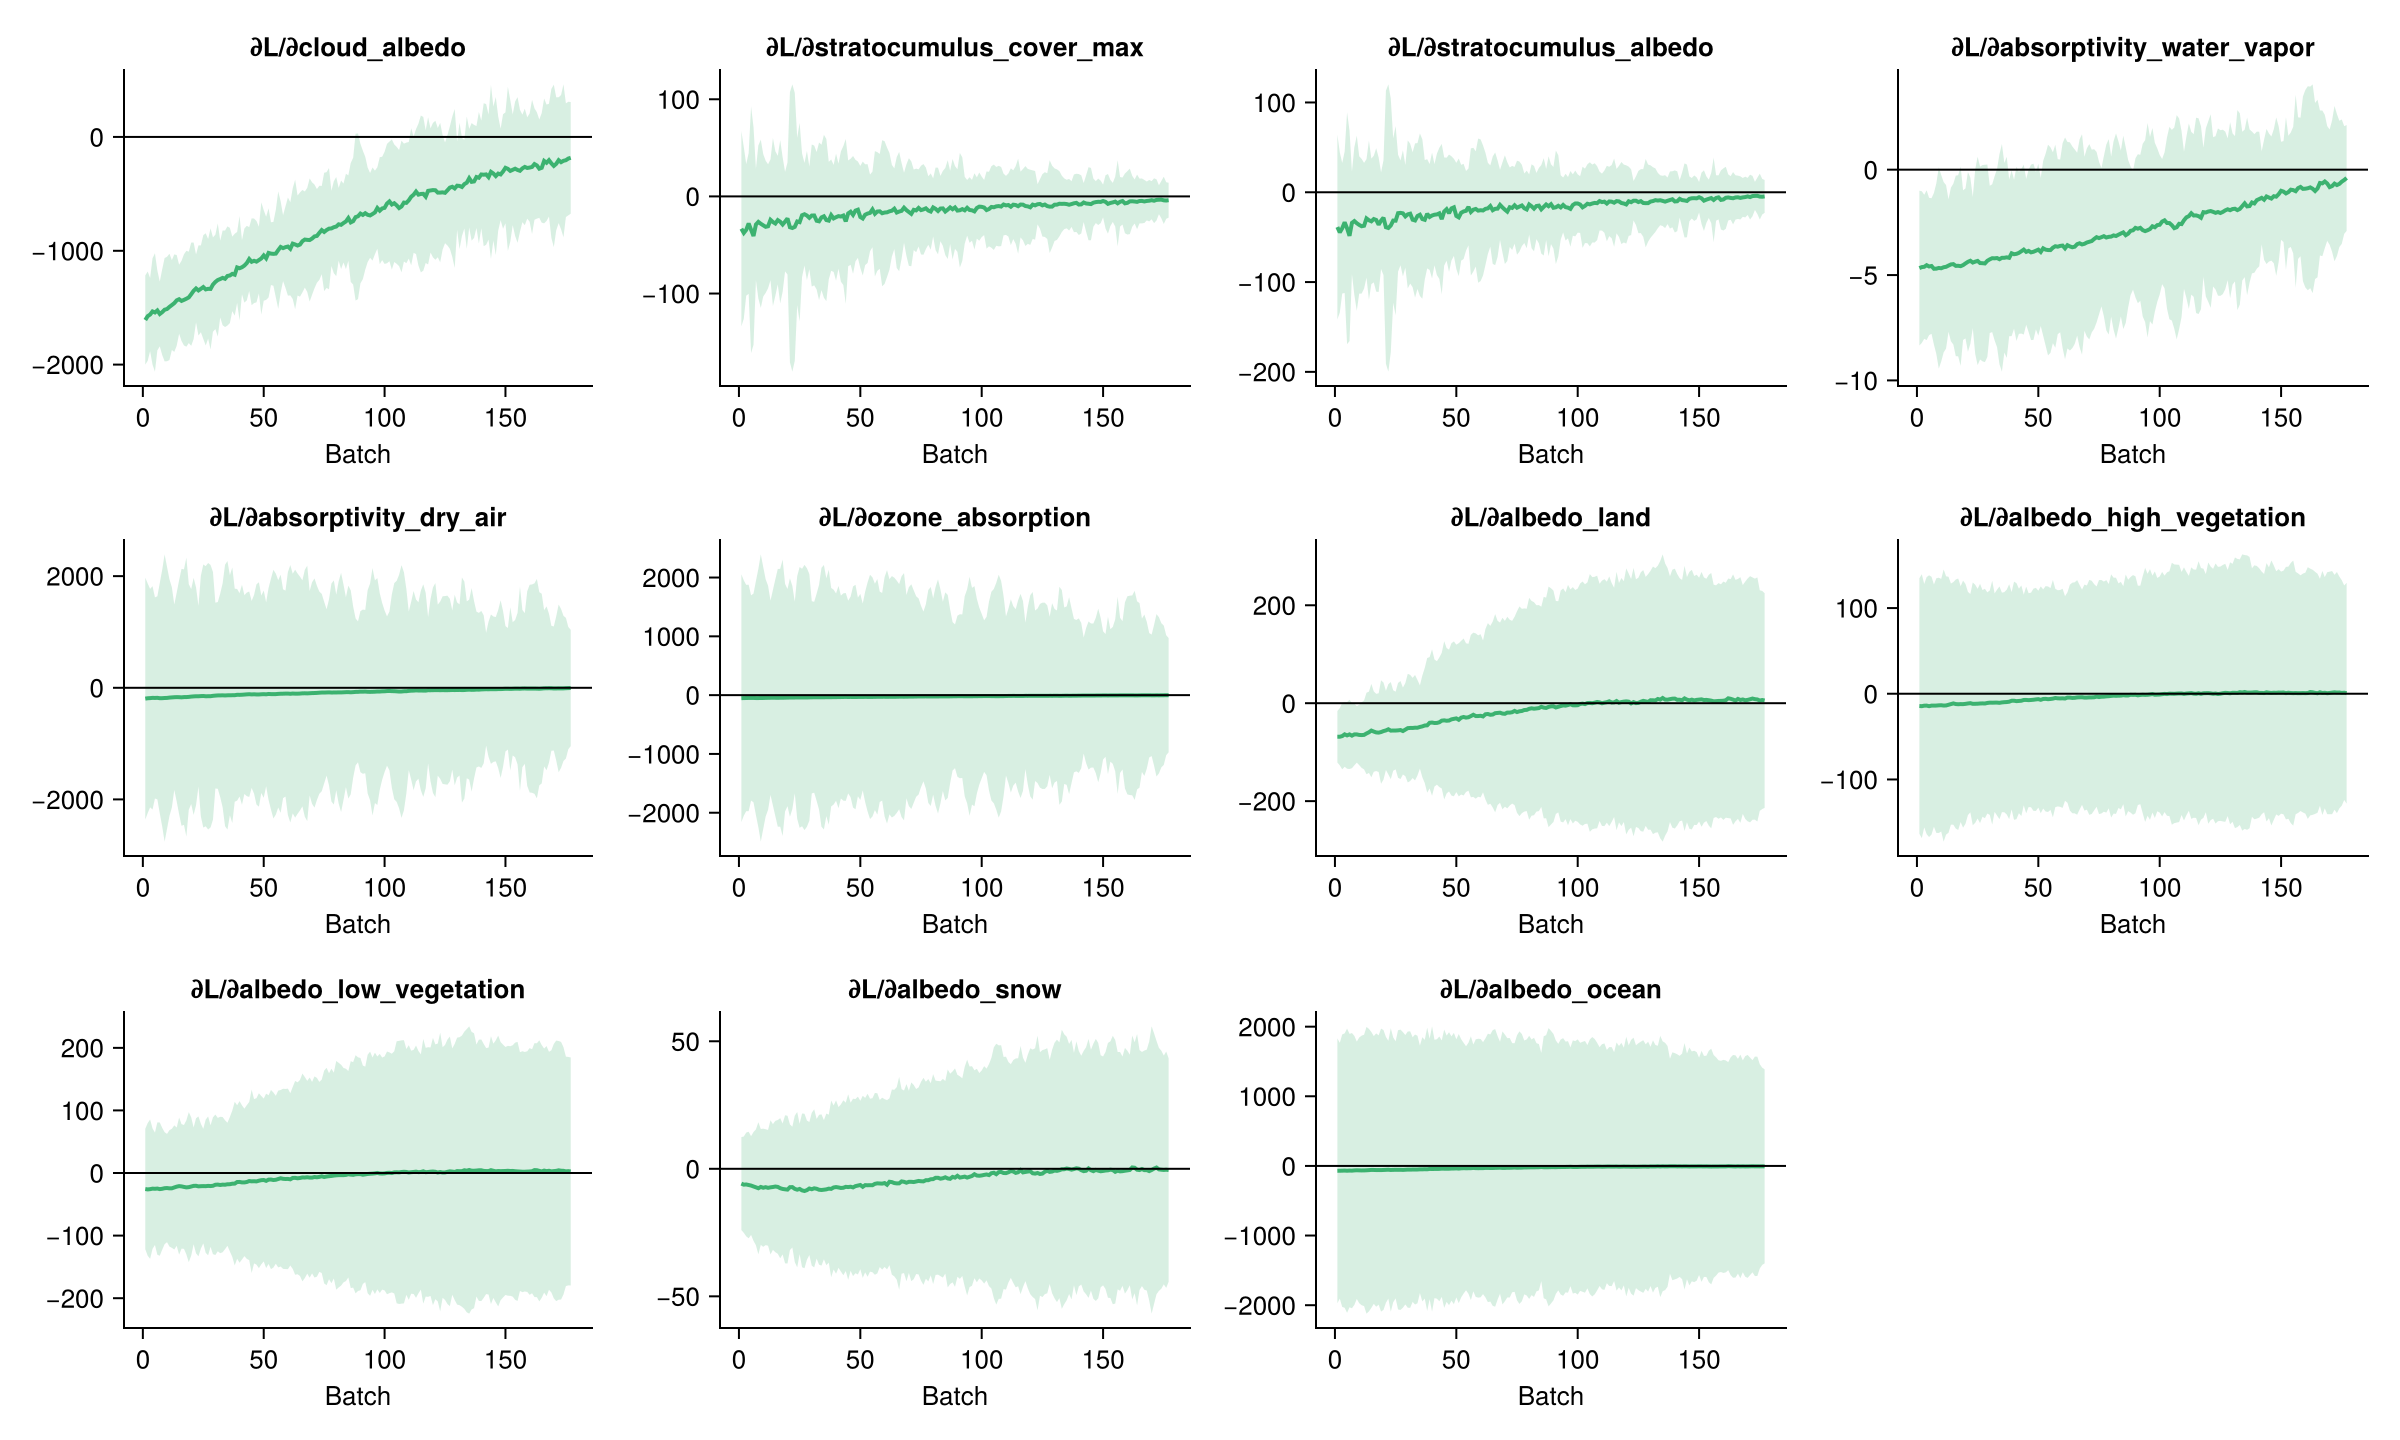

In [12]:
figs.fig_grads

## 8. Climate Validation

Training optimises a loss over short (3-day) windows. A good short-window loss does **not** guarantee a good equilibrium climatology. We run a fresh 7-year simulation with the trained parameters and compare the equilibrium statistics to the default model.

**⏱ Expected runtime: ~1–2 hours at T31 (two 7-year runs in sequence).**

In [13]:
clm = run_climate_validation(result; n_years=7, stat_years=5)

Climate run: default ...


  52%  ETA: 0:05:05 (2003-11-08, 952.33 years/day, 106 m/s, [ -98,   41] ˚C)┌ Warning: NaN or Inf detected at time step 47803 (2003-11-08T21:20:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/NZC9j/src/output/feedback.jl:123
 100% Time: 0:05:30 (2007-03-20, 1831.82 years/day, NaN m/s, [ NaN,  NaN] ˚C)


Climate run: trained ...


  48%  ETA: 0:05:08 (2003-08-02, 1018.23 years/day, 109 m/s, [ -98,   33] ˚C)┌ Warning: NaN or Inf detected at time step 44269 (2003-08-02T17:20:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/NZC9j/src/output/feedback.jl:123
 100% Time: 0:04:45 (2007-03-20,  2.12 millenia/day, NaN m/s, [ NaN,  NaN] ˚C)


(default = (osr = 78.46798f0, olr = 696.46173f0, srd = 171.55344f0, sru = 17.490732f0, lwd = 356.37637f0, lwu = 401.26602f0, precip_total = 3.899434f0, temp_profile = Float32[NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN]), trained = (osr = 96.67171f0, olr = 1082.0309f0, srd = 168.46179f0, sru = 22.533129f0, lwd = 357.64865f0, lwu = 387.39703f0, precip_total = 3.3685274f0, temp_profile = Float32[NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lwd, lwu, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lwd, lwu, precip_total, precip_con

In [14]:
# Print bias table
targets = result.loss_config.targets
@printf("%-6s  %8s  %8s  %8s  %8s\n",
        "flux", "target", "default", "trained", "improvement")
println("-" ^ 52)
for k in result.loss_config.flux_keys
    tgt   = targets[k]
    d_val = getproperty(clm.default, k)
    t_val = getproperty(clm.trained, k)
    d_bias = d_val - tgt
    t_bias = t_val - tgt
    impr  = abs(d_bias) - abs(t_bias)
    @printf("%-6s  %8.2f  %8.2f  %8.2f  %+8.2f\n",
            k, tgt, d_val, t_val, impr)
end

flux      target   default   trained  improvement
----------------------------------------------------
osr       101.90     78.47     96.67    +18.20
sru        23.00     17.49     22.53     +5.04
srd       168.00    171.55    168.46     +3.09


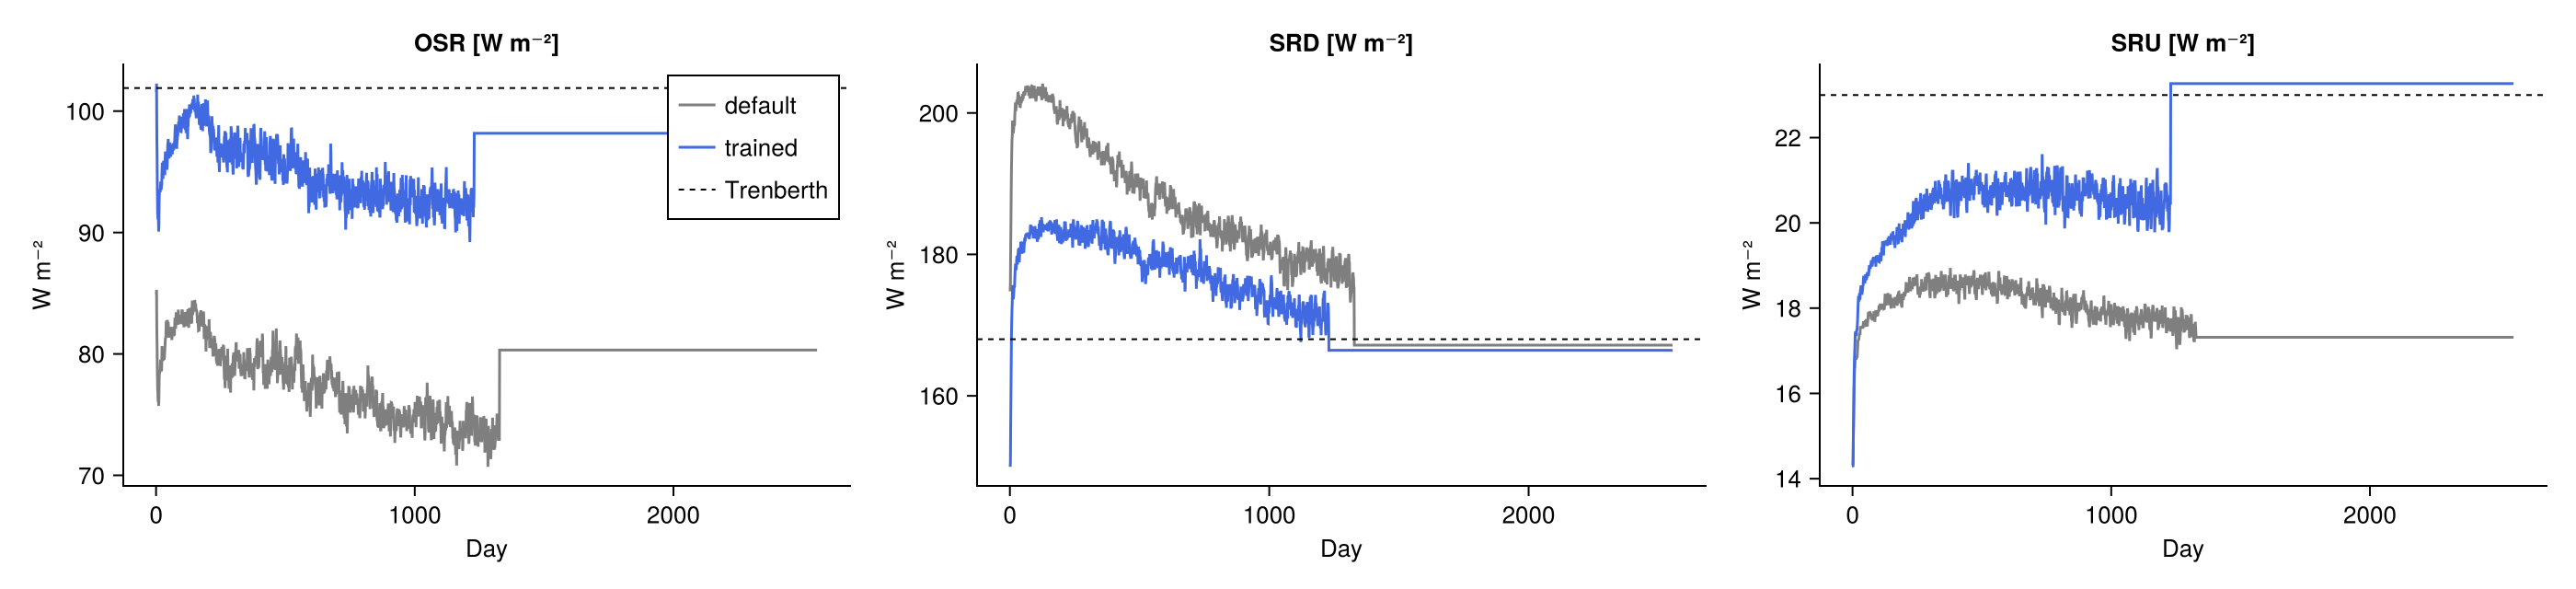

In [15]:
cfigs = plot_climate(clm;
    save_dir    = joinpath(@__DIR__, "output", "radiation_sw"),
    loss_config = result.loss_config,
)
cfigs.fig_rad

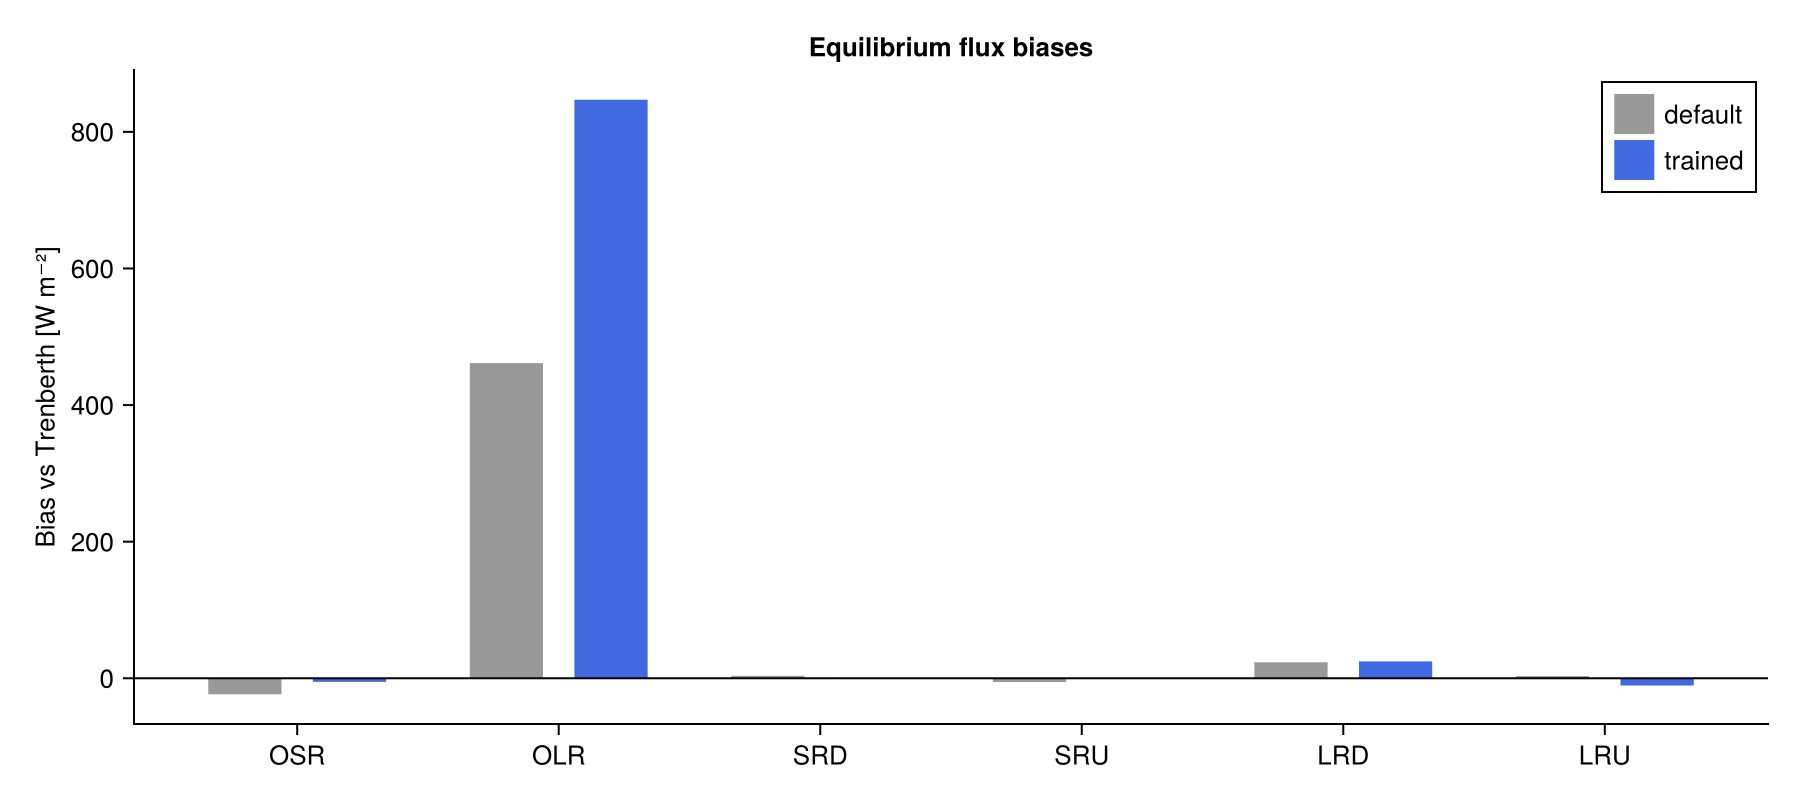

In [16]:
cfigs.fig_summary

## 9. Next Steps

- **Check held-out diagnostics.** Look at `cfigs.fig_lw` and precipitation. If new biases appeared in fluxes that weren't in the loss, augment `OSR_SRU_SRD_LOSS` with those terms and re-run.
- **Try `TRENBERTH_LOSS`.** Add longwave parameters and optimise all 6 fluxes simultaneously — see `examples/trenberth_full.ipynb`.
- **Adjust learning rate.** If `figs.fig_loss` shows oscillation, reduce the Adam LR to `1f-3`. If convergence is slow after LR decay, try `1f-2` at the start.
- **Restart from trained values.** Set `initial = result.final_params[spec.name]` for each spec to continue from where this run stopped.